<a href="https://colab.research.google.com/github/Ysravanthi15/Health-Care-Analytics-For-Doctor-Visits/blob/main/Healthcare_Analytics_for_Doctor_Visits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df=pd.read_csv("/content/Healthcare Analytics for Doctor Visits dataset.csv")

In [34]:
df.head()


,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


In [35]:
#Last Five rows
df.tail()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
5185,5186,0,female,0.22,0.55,0,0,0,no,no,no,no,no
5186,5187,0,male,0.27,1.30,0,0,1,no,no,no,no,no
5187,5188,0,female,0.37,0.25,1,0,1,no,no,yes,no,no
5188,5189,0,female,0.52,0.65,0,0,0,no,no,no,no,no
5189,5190,0,male,0.72,0.25,0,0,0,no,no,yes,no,no


In [36]:
df.shape


(5190, 13)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   object 
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   object 
 9   freepoor    5190 non-null   object 
 10  freerepat   5190 non-null   object 
 11  nchronic    5190 non-null   object 
 12  lchronic    5190 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 527.2+ KB


In [38]:
#Statistical information
df.describe()

,Unnamed: 0,visits,age,income,illness,reduced,health
count,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000
mean,2595.500000,0.301734,0.406385,0.583160,1.431985,0.861850,1.217534
std,1498.368279,0.798134,0.204782,0.368907,1.384152,2.887628,2.124266
min,1.000000,0.000000,0.190000,0.000000,0.000000,0.000000,0.000000
25%,1298.250000,0.000000,0.220000,0.250000,0.000000,0.000000,0.000000
50%,2595.500000,0.000000,0.320000,0.550000,1.000000,0.000000,0.000000
75%,3892.750000,0.000000,0.620000,0.900000,2.000000,0.000000,2.000000
max,5190.000000,9.000000,0.720000,1.500000,5.000000,14.000000,12.000000


In [39]:
#Checking the Null Values
df.isnull().sum()

,0
Unnamed: 0,0
visits,0
gender,0
age,0
income,0
illness,0
reduced,0
health,0
private,0
freepoor,0


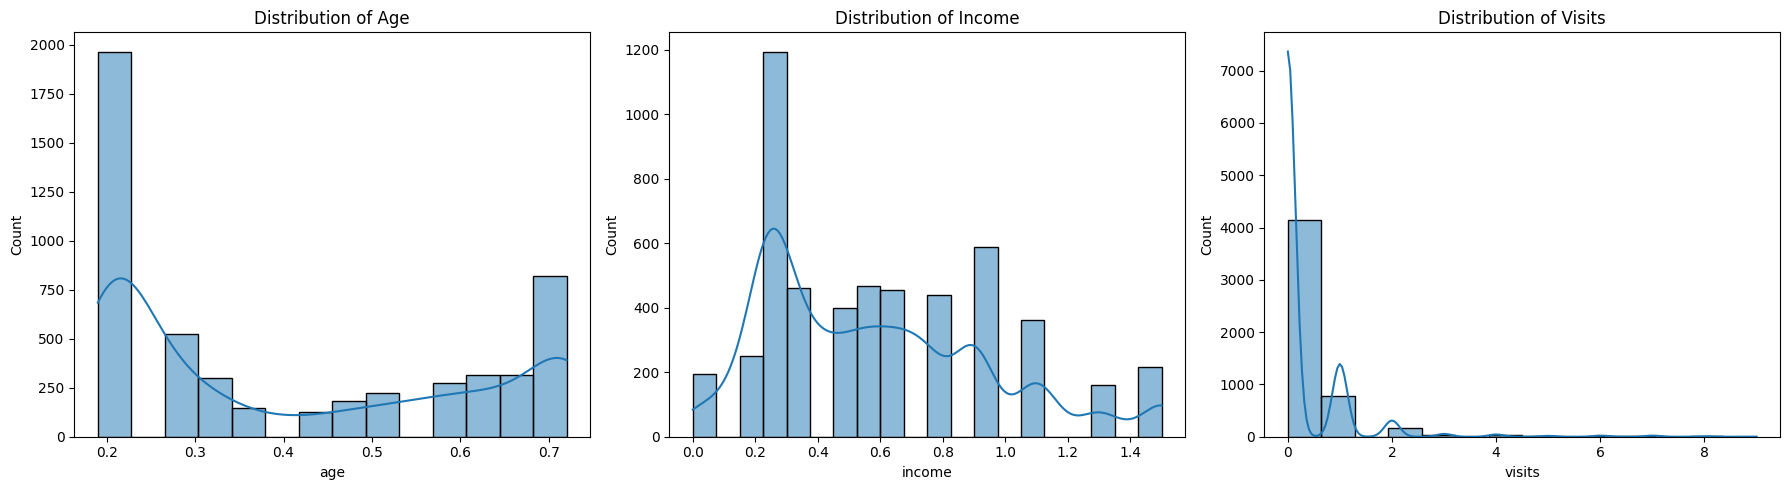

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['age'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Age')

sns.histplot(df['income'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Income')

sns.histplot(df['visits'], kde=True, ax=axes[2])
axes[2].set_title('Distribution of Visits')

plt.tight_layout()
plt.show()

,gender,count,mean,median
0,female,2702,0.361954,0.0
1,male,2488,0.236334,0.0


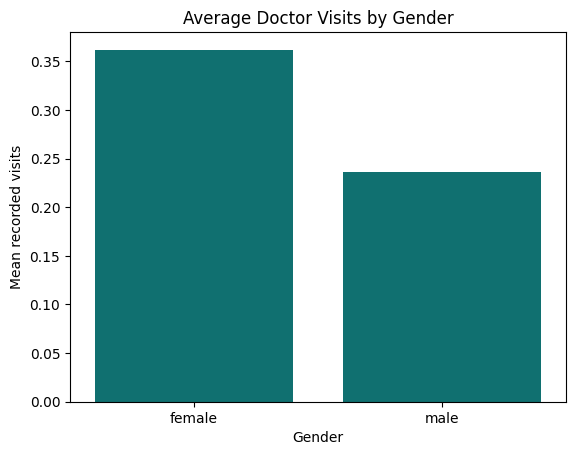

In [41]:
gender_analysis = (
    df.groupby("gender")["visits"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

display(gender_analysis)

sns.barplot(
    data=gender_analysis,
    x="gender",
    y="mean",
    color="teal"
)

plt.title("Average Doctor Visits by Gender")
plt.xlabel("Gender")
plt.ylabel("Mean recorded visits")
plt.show()

,illness,count,mean
0,0,1554,0.078507
1,1,1638,0.295482
2,2,946,0.403805
3,3,542,0.420664
4,4,274,0.576642
5,5,236,0.813559


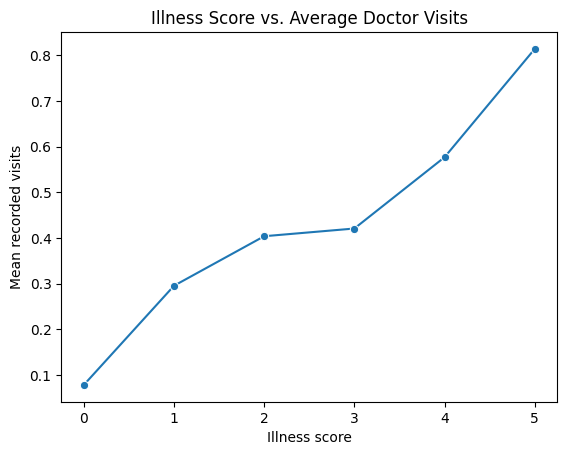

In [42]:
illness_analysis = (
    df.groupby("illness")["visits"]
    .agg(["count", "mean"])
    .reset_index()
)

display(illness_analysis)

sns.lineplot(
    data=illness_analysis,
    x="illness",
    y="mean",
    marker="o"
)

plt.title("Illness Score vs. Average Doctor Visits")
plt.xlabel("Illness score")
plt.ylabel("Mean recorded visits")
plt.show()

### Multivariate Analysis: Pairplot of Age, Income, and Visits by Gender

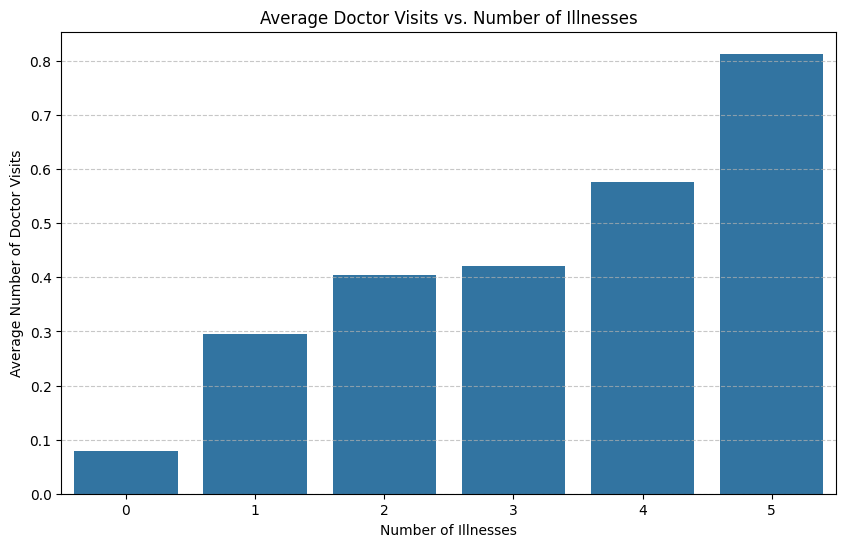

In [43]:

# Calculate the average doctor visits for each illness score
average_visits_by_illness = df.groupby('illness')['visits'].mean().reset_index()

# Create a bar plot to visualize the relationship
plt.figure(figsize=(10, 6))
sns.barplot(x='illness', y='visits', data=average_visits_by_illness)
plt.title('Average Doctor Visits vs. Number of Illnesses')
plt.xlabel('Number of Illnesses')
plt.ylabel('Average Number of Doctor Visits')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

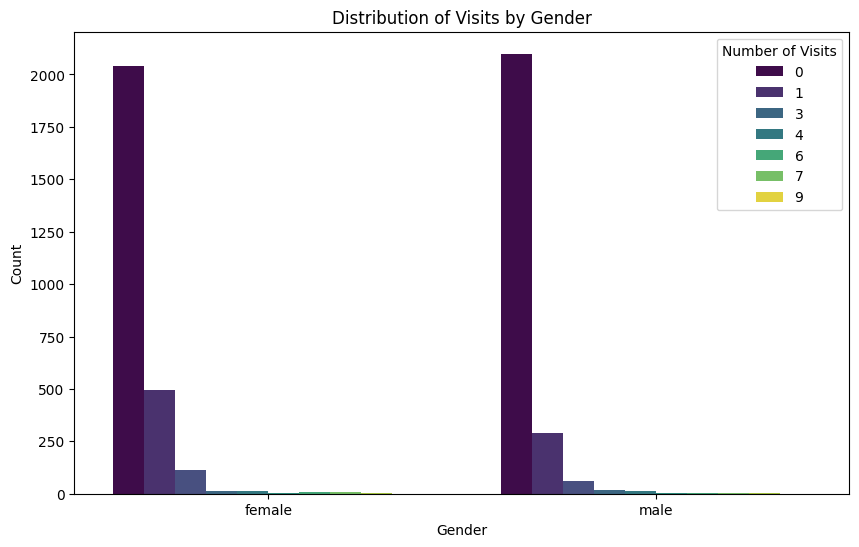

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Multivariate plot 1: Relationship between gender and visits
plt.figure(figsize=(10, 6))
sns.countplot(x='gender', hue='visits', data=df, palette='viridis')
plt.title('Distribution of Visits by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Number of Visits')
plt.show()

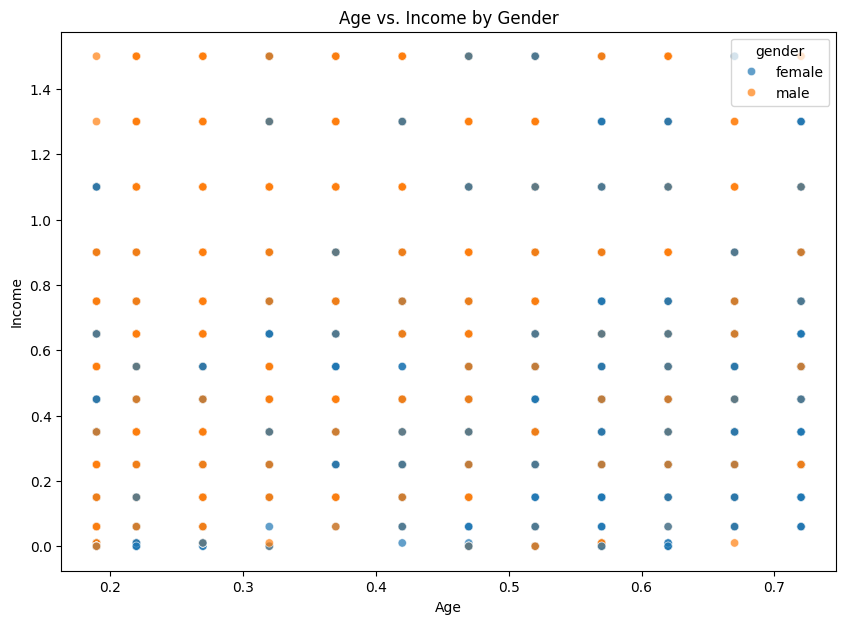

In [45]:
# Multivariate plot 2: Relationship between age, income, and gender
plt.figure(figsize=(10, 7))
sns.scatterplot(x='age', y='income', hue='gender', data=df, alpha=0.7)
plt.title('Age vs. Income by Gender')
plt.xlabel('Age')
plt.ylabel('Income')
plt.show()

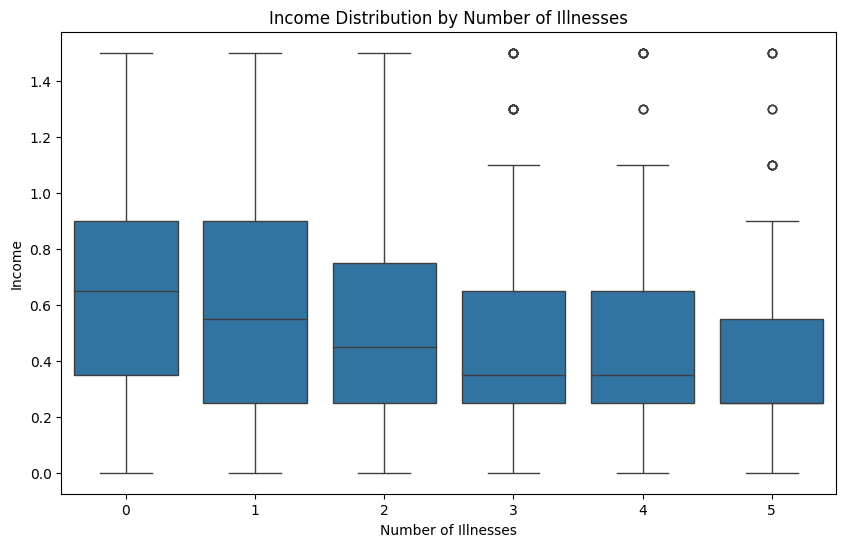

In [46]:

# Multivariate plot 3: Relationship between income and illness
plt.figure(figsize=(10, 6))
sns.boxplot(x='illness', y='income', data=df)
plt.title('Income Distribution by Number of Illnesses')
plt.xlabel('Number of Illnesses')
plt.ylabel('Income')
plt.show()

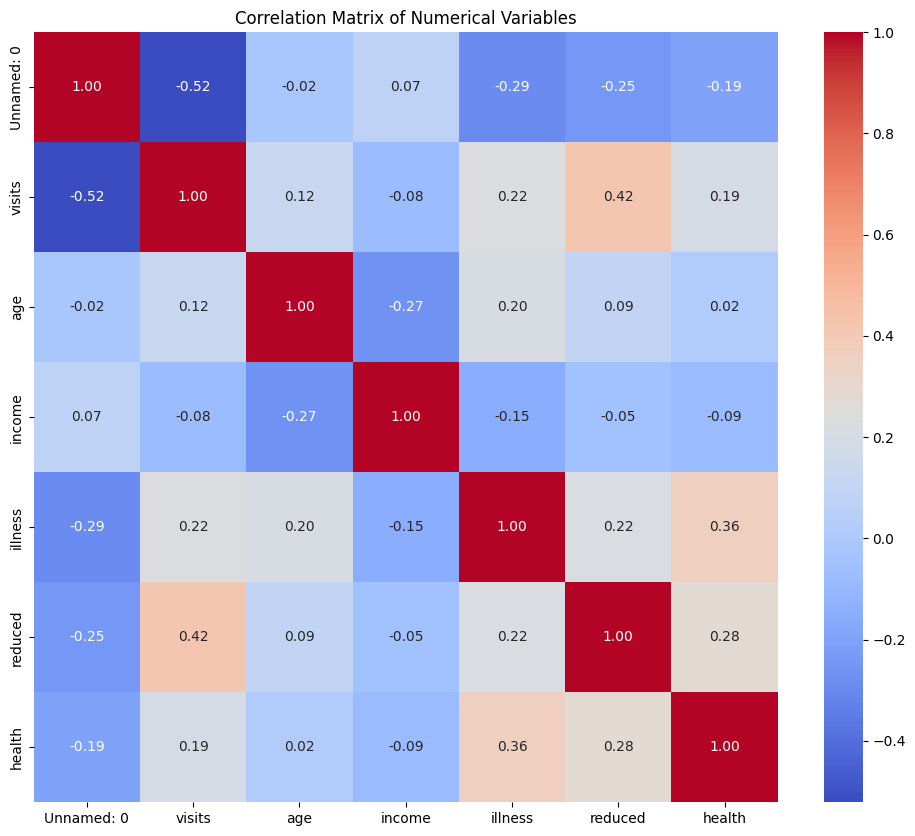

In [47]:

# Select only numerical columns for correlation analysis
numerical_df = df.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Plot the correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Variables')
plt.show()